# Utilizar otro dataset y poner en práctica la generación de secuencias con la estategias presentadas.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import nltk
import keras
from keras.src.legacy.preprocessing.text import text_to_word_sequence, Tokenizer
from keras.api.preprocessing.sequence import pad_sequences
# from tensorflow.keras.preprocessing.text import text_to_word_sequence
# from tensorflow.python.keras.preprocessing.text import Tokenizer
# from keras_preprocessing.sequence import pad_sequences # se utilizará para padding

from keras.api.models import Sequential
from keras.api.layers import Dense, LSTM, Embedding, Dropout
from keras.api.losses import SparseCategoricalCrossentropy

In [5]:
# nltk.set_proxy('http://127.0.0.1:3128')
nltk.download('mte_teip5')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package mte_teip5 to /root/nltk_data...
[nltk_data]   Package mte_teip5 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
orwell_sents = nltk.corpus.multext_east.sents('oana-en.xml')
str(orwell_sents[0])

"['It', 'was', 'a', 'bright', 'cold', 'day', 'in', 'April', ',', 'and', 'the', 'clocks', 'were', 'striking', 'thirteen', '.']"

In [7]:
nltk.word_tokenize(' '.join(orwell_sents[0]))

['It',
 'was',
 'a',
 'bright',
 'cold',
 'day',
 'in',
 'April',
 ',',
 'and',
 'the',
 'clocks',
 'were',
 'striking',
 'thirteen',
 '.']

In [8]:
# Se tuvo la intención de usar word_tokenizer de ntlk, sin embargo, esta función no elimina las puntuaciónes ni convierte el texto en minúscula. Por lo tanto se decidió utilizar text_to_word_sequence de keras
segmented_sentences = [text_to_word_sequence(' '.join(orwell_sent)) for orwell_sent in orwell_sents]
print(segmented_sentences[0])

['it', 'was', 'a', 'bright', 'cold', 'day', 'in', 'april', 'and', 'the', 'clocks', 'were', 'striking', 'thirteen']


In [9]:
length_sentences = [len(sentence) for sentence in segmented_sentences]

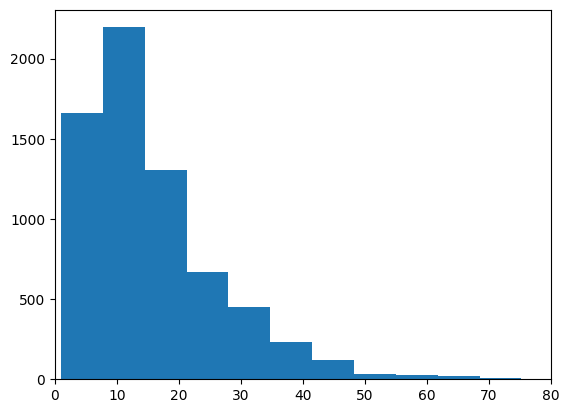

In [10]:
# podemos ver su distribución
plt.hist(length_sentences,bins=20)
plt.xlim(0, 80)
plt.show()

In [15]:
# Utilizamos pertcentil 75 para configurar el tamaño maximo de palabras en la sentencia. Probamos con el percentil 90 pero nos dio 29
# un valor elevado para el hardware disponible
max_context_size = int(np.percentile(length_sentences, 75)-1)
print(f'max_context_size: {max_context_size}')

max_context_size: 29


###  Tokenizar

In [70]:
# instanciamos el tokenizador
tok = Tokenizer()

# El tokenizer "aprende" las palabras que se usaran
# Se construye (fit) una vez por proyecto, se aplica N veces (tal cual un encoder)
# El token 0 es reservado y no es asignado. Se utiliza para designar a palabras
# fuera del vocabulario aprendido
tok.fit_on_texts(segmented_sentences)

# Convertimos las palabras a números
# entran palabras -> salen números
tokenized_sentences = tok.texts_to_sequences(segmented_sentences)

In [75]:
tokenized_sentences[0]

[8, 6, 3, 1426, 510, 141, 9, 1839, 4, 1, 3434, 22, 3435, 4903]

In [76]:
tokenized_sentences_train, tokenized_sentences_val, _, _ = train_test_split(tokenized_sentences, tokenized_sentences, test_size=0.15, random_state=42)


In [77]:
len(tokenized_sentences_train)

5726

In [78]:
tok_sent = []

for sent in tokenized_sentences_train:

  # si la secuencia tiene más términos que el tamaño de contexto máximo,
  # armo varias sub-secuencias de tamaño máximo
  if len(sent) > (max_context_size+1):
    extra = len(sent)-(max_context_size+1) + 1
    for i in range(extra):
      tok_sent.append(sent[i:i+max_context_size+1])
  # elif len(sent) == max_context_size +1: # si la secuencia tiene mismo tamaño que max_context, dejo la secuencia como está
  else:
    tok_sent.append(sent)


In [79]:
len(tok_sent)

12024

In [80]:
tok_sent_augm = []

for sent in tok_sent:

  # generamos todas las sub-secuencias
  subseq = [sent[:i+2] for i in range(len(sent)-1)]
  # en esta línea paddeamos al tamaño de contexto máximo
  tok_sent_augm.append(pad_sequences(subseq, maxlen=max_context_size+1, padding='pre'))

In [81]:
len(tok_sent_augm)

12024

In [83]:
# train_seqs = np.array(tok_sent_augm)
train_seqs = np.concatenate(tok_sent_augm, axis=0)

In [84]:
train_seqs.shape

(259887, 30)

In [85]:
X = train_seqs[:,:-1]
y = train_seqs[:,1:]

In [20]:
tok.index_word

{1: 'the',
 2: 'of',
 3: 'a',
 4: 'and',
 5: 'to',
 6: 'was',
 7: 'he',
 8: 'it',
 9: 'in',
 10: 'that',
 11: 'had',
 12: 'his',
 13: 'you',
 14: 'not',
 15: 'with',
 16: 'as',
 17: 'for',
 18: 'at',
 19: 'they',
 20: 'be',
 21: 'but',
 22: 'were',
 23: 'is',
 24: 'on',
 25: 'there',
 26: 'winston',
 27: 'him',
 28: 'i',
 29: 'which',
 30: 'or',
 31: "'s",
 32: 'one',
 33: 'by',
 34: 'all',
 35: 'could',
 36: 'from',
 37: 'her',
 38: 'been',
 39: 'she',
 40: 'no',
 41: 'have',
 42: 'would',
 43: 'out',
 44: 'said',
 45: 'an',
 46: 'what',
 47: 'up',
 48: 'when',
 49: 'even',
 50: 'are',
 51: 'this',
 52: 'party',
 53: 'them',
 54: 'into',
 55: 'their',
 56: 'if',
 57: 'we',
 58: 'any',
 59: 'did',
 60: 'only',
 61: 'like',
 62: 'down',
 63: 'more',
 64: 'so',
 65: "o'brien",
 66: 'time',
 67: 'thought',
 68: 'face',
 69: 'some',
 70: 'then',
 71: 'never',
 72: 'will',
 73: 'do',
 74: 'again',
 75: 'seemed',
 76: 'two',
 77: 'other',
 78: 'its',
 79: 'your',
 80: 'over',
 81: 'than',
 8

In [41]:
vocab_size = len(tok.word_counts)
print(vocab_size)


8905


In [22]:
print(tok.word_docs)

defaultdict(<class 'int'>, {'and': 1822, 'was': 1883, 'were': 570, 'clocks': 2, 'it': 1625, 'april': 5, 'striking': 2, 'day': 82, 'a': 1887, 'bright': 7, 'cold': 22, 'in': 1550, 'the': 3576, 'thirteen': 1, 'winston': 524, 'to': 1829, 'chin': 3, 'though': 124, 'through': 95, 'swirl': 1, 'mansions': 6, 'quickly': 16, 'him': 442, 'vile': 2, 'wind': 9, 'into': 270, 'prevent': 9, 'from': 391, 'enough': 63, 'doors': 5, 'an': 314, 'effort': 27, 'glass': 47, 'dust': 19, 'along': 15, 'breast': 11, 'with': 719, 'slipped': 10, 'nuzzled': 1, 'of': 2402, 'his': 873, 'victory': 38, 'entering': 3, 'gritty': 3, 'smith': 16, 'not': 794, 'escape': 8, 'hallway': 1, 'cabbage': 6, 'smelt': 4, 'boiled': 5, 'old': 109, 'mats': 1, 'rag': 1, 'been': 376, 'tacked': 1, 'large': 39, 'wall': 34, 'had': 1121, 'poster': 10, 'display': 2, 'too': 77, 'indoor': 1, 'for': 614, 'one': 388, 'at': 610, 'end': 70, 'coloured': 10, 'ruggedly': 1, 'metre': 6, 'face': 186, 'enormous': 42, 'moustache': 4, 'heavy': 24, 'man': 143

### Definimos modelo

In [95]:
model = Sequential()


model.add(Embedding(input_dim=vocab_size+1, output_dim=10, input_shape=(max_context_size,)))

model.add(LSTM(100, return_sequences=True))
# model.add(Dropout(0.2))
model.add(LSTM(100, return_sequences=True))
model.add(Dense(vocab_size+1, activation='softmax'))

# Clasificación multiple categórica --> loss = categorical_crossentropy
# notar que usamos la versión Sparse para utilizar sólo índices en lugar de OHE
model.compile(loss=SparseCategoricalCrossentropy(), optimizer='adam')

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 29, 10)              │          89,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 29, 100)             │          44,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 29, 100)             │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 29, 8906)            │         899,506 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,113,366 (4.25 MB)

 Trainable params: 1,113,366 (4.25 MB)

 Non-trainable params: 0 (0.00 B)

In [91]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, patience=10, max_val_size=2500):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad y la paciencia para detener el entrenamiento.
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.history_ppl = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(len_seq)]
        self.target.extend([seq[i] for i in range(len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)
      # A efecto de evitar un consumo excesivo de memorial limitamos el
      # tamaño maximo de self.padded
      if len(self.padded) > max_val_size:
          self.padded = self.padded[:max_val_size]
          self.target = self.target[:max_val_size]
          self.info = self.info[:max_val_size]


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True

### Entrenamiento

In [ ]:
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=30)

Epoch 1/20
8659/8663 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0270
 mean perplexity: 734.1313766390059 

Saved new model!
8663/8663 ━━━━━━━━━━━━━━━━━━━━ 111s 12ms/step - loss: 4.0268
Epoch 2/20
8659/8663 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6521
 mean perplexity: 2580.5281707223685 

8663/8663 ━━━━━━━━━━━━━━━━━━━━ 111s 13ms/step - loss: 2.6521
Epoch 3/20
8661/8663 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.2528
 mean perplexity: 12643.160873645009 

8663/8663 ━━━━━━━━━━━━━━━━━━━━ 141s 13ms/step - loss: 2.2527
Epoch 4/20
8663/8663 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8694
 mean perplexity: 32431.040869426648 

8663/8663 ━━━━━━━━━━━━━━━━━━━━ 144s 13ms/step - loss: 1.8694
Epoch 5/20
8662/8663 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.5222
 mean perplexity: 48661.75804763643 

8663/8663 ━━━━━━━━━━━━━━━━━━━━ 139s 13ms/step - loss: 1.5222
Epoch 6/20
8659/8663 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2971
 mean perplexity: 87722.0323283797 

8663/8663 ━━━━━━━━━━━━━━━━━━

In [52]:
print(history_ppl)

[25220.6980820807, 16133.935974708427, 27724.04123304226, 19463.13306450698, 21951.104302324435, 44898.04381215734, 25884.16236760035, 45496.64720216642, 66679.31857453274, 64882.44696455473, 80125.98223050883, 86794.55359961245]


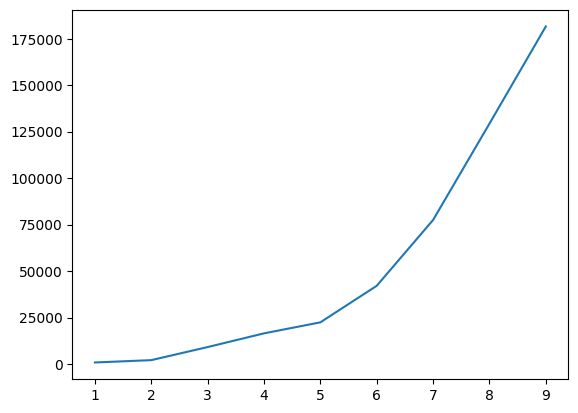

In [90]:
import seaborn as sns

# Podemos graficar la evolución de la perplejidad con las épocas.
# Recordar que el valor de perplejidad del modelo trivial es el tamaño del vocabulario.
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()